In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### LOAD DATA

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.info())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

### DATA CLEANING

In [3]:
df.columns = df.columns.str.strip()
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
df.drop_duplicates(inplace=True)
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### FEATURE ENGINEERING

In [4]:
df["churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})
df["avg_spend_per_month"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)
df["customer_lifetime_value"] = (
    df["MonthlyCharges"] *
    df["tenure"]
)
df["is_long_term_customer"] = np.where(
    df["tenure"] >= 24,
    1,
    0
)

### DATA VISUALIZATION

C:\Users\arish\AppData\Local\Temp\ipykernel_1100\652105986.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


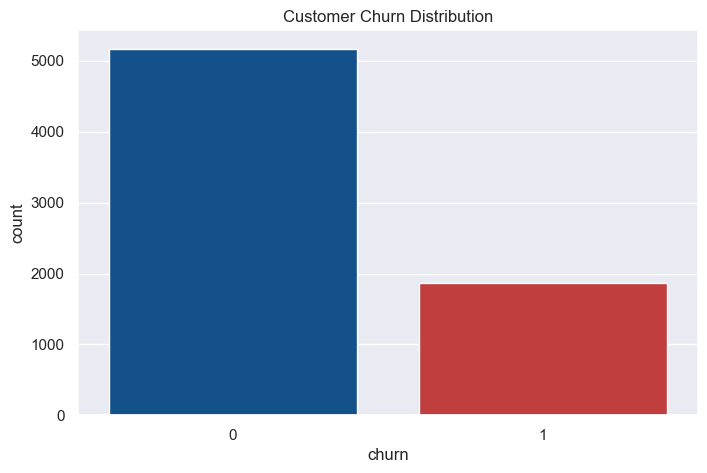

In [6]:
sns.set_theme(style="darkgrid")

colors = {
    "blue":"#00509D",
    "red":"#D62828",
    "green":"#2A9D8F",
    "orange":"#F77F00"
}
plt.figure(figsize=(8,5))

sns.countplot(
    x="churn",
    data=df,
    palette=[colors["blue"], colors["red"]]
)

plt.title("Customer Churn Distribution")
plt.show()


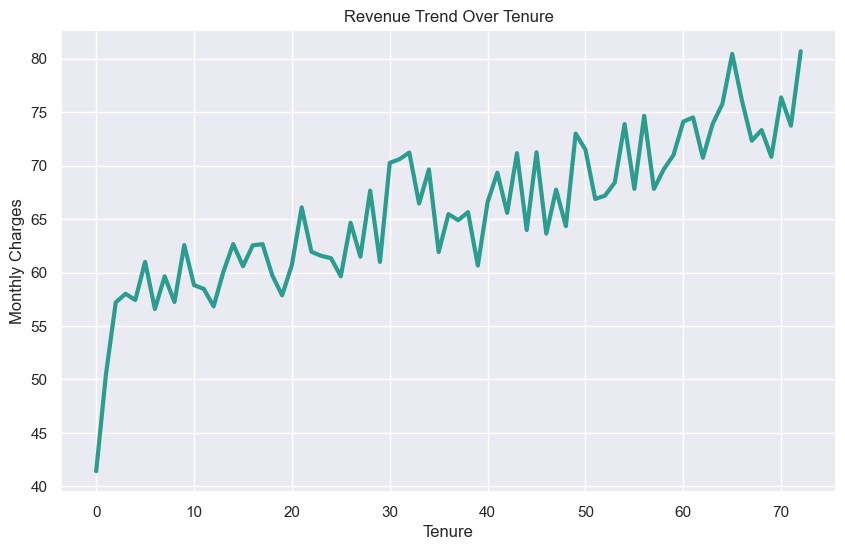

In [7]:
plt.figure(figsize=(10,6))

df.groupby("tenure")["MonthlyCharges"].mean().plot(
    color=colors["green"],
    linewidth=3
)

plt.title("Revenue Trend Over Tenure")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

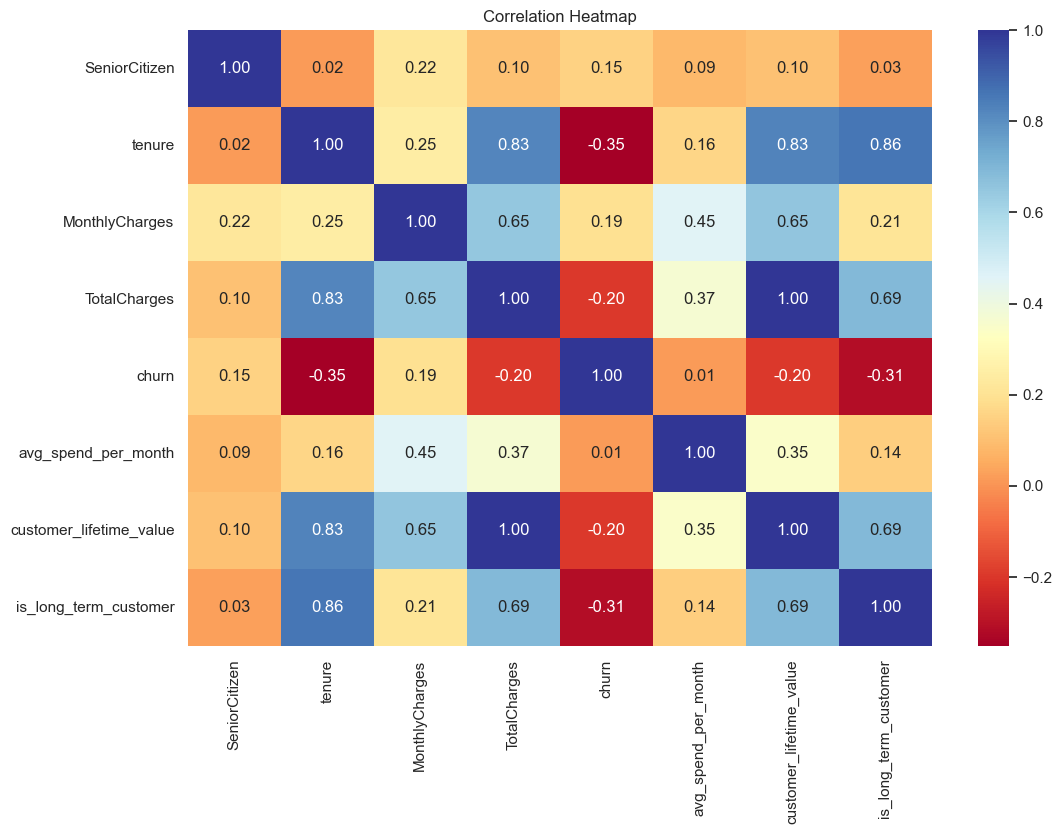

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="RdYlBu",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

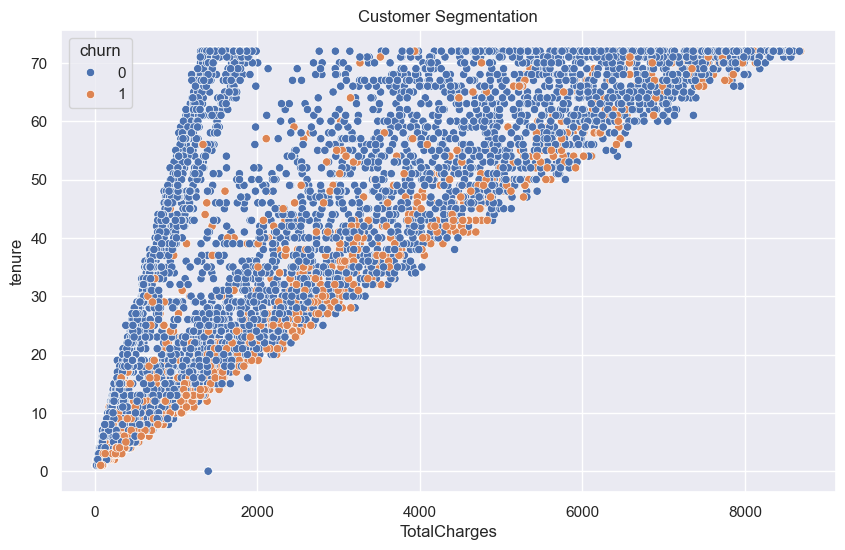

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="TotalCharges",
    y="tenure",
    hue="churn",
    data=df
)

plt.title("Customer Segmentation")
plt.show()

### CUSTOMER SEGMENTATION

In [10]:
def segment(row):

    if row["TotalCharges"] > df["TotalCharges"].quantile(0.70):
        return "High Value"

    elif row["TotalCharges"] > df["TotalCharges"].quantile(0.30):
        return "Medium Value"

    else:
        return "Low Value"

df["customer_segment"] = df.apply(
    segment,
    axis=1
)

print(df["customer_segment"].value_counts())


customer_segment
Medium Value    2818
Low Value       2113
High Value      2112
Name: count, dtype: int64


### MACHINE LEARNING DATA PREP

In [11]:
X = df.drop(
    [
        "customerID",
        "Churn",
        "churn",
        "customer_segment"
    ],
    axis=1
)

y = df["churn"]
X = pd.get_dummies(
    X,
    drop_first=True
)
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### MODEL 1 - LOGISTIC REGRESSION

In [12]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(X_test)

### MODEL 2 - RANDOM FOREST

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

### EVALUATION FUNCTION

In [14]:
def evaluate(
    y_true,
    y_pred,
    model_name
):

    print("\n", model_name)

    print(
        "Accuracy:",
        accuracy_score(y_true,y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true,y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true,y_pred)
    )

    print(
        "F1 Score:",
        f1_score(y_true,y_pred)
    )

In [15]:
evaluate(
    y_test,
    pred_lr,
    "Logistic Regression"
)

evaluate(
    y_test,
    pred_rf,
    "Random Forest"
)


 Logistic Regression
Accuracy: 0.8126330731014905
Precision: 0.6775244299674267
Recall: 0.5576407506702413
F1 Score: 0.611764705882353

 Random Forest
Accuracy: 0.794180269694819
Precision: 0.6554307116104869
Recall: 0.4691689008042895
F1 Score: 0.546875


### ROC-AUC SCORE

In [16]:
print(
    roc_auc_score(
        y_test,
        lr.predict_proba(X_test)[:,1]
    )
)

print(
    roc_auc_score(
        y_test,
        rf.predict_proba(X_test)[:,1]
    )
)

0.8624336228223628
0.8401940335586447


### Confusion Matrix

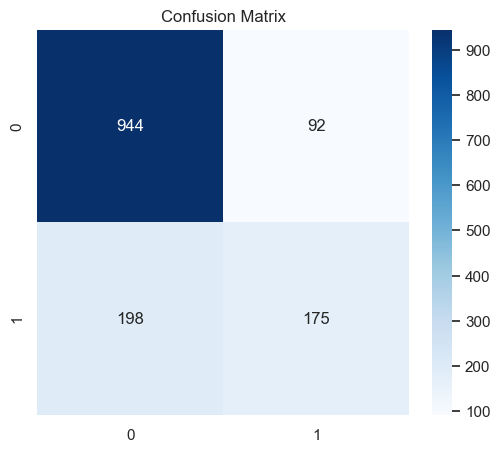

In [18]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

### Churn Probability

In [19]:
X_scaled = scaler.transform(X)

df["churn_probability"] = (
    rf.predict_proba(X_scaled)[:,1]
)

### Risk Classification

In [20]:
def risk(prob):

    if prob > 0.70:
        return "High Risk"

    elif prob > 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

df["risk_category"] = (
    df["churn_probability"]
    .apply(risk)
)

### Risk Category Graph

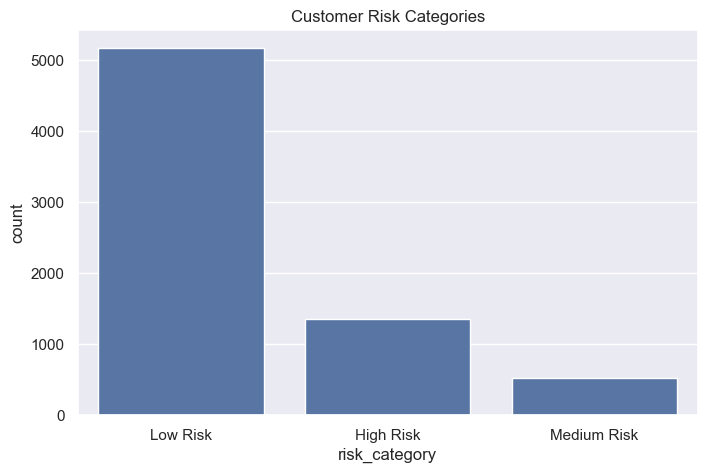

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="risk_category",
    data=df
)

plt.title(
    "Customer Risk Categories"
)

plt.show()

### Feature Importance

In [22]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":
    rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

### Feature Importance Graph

C:\Users\arish\AppData\Local\Temp\ipykernel_1100\4209011766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


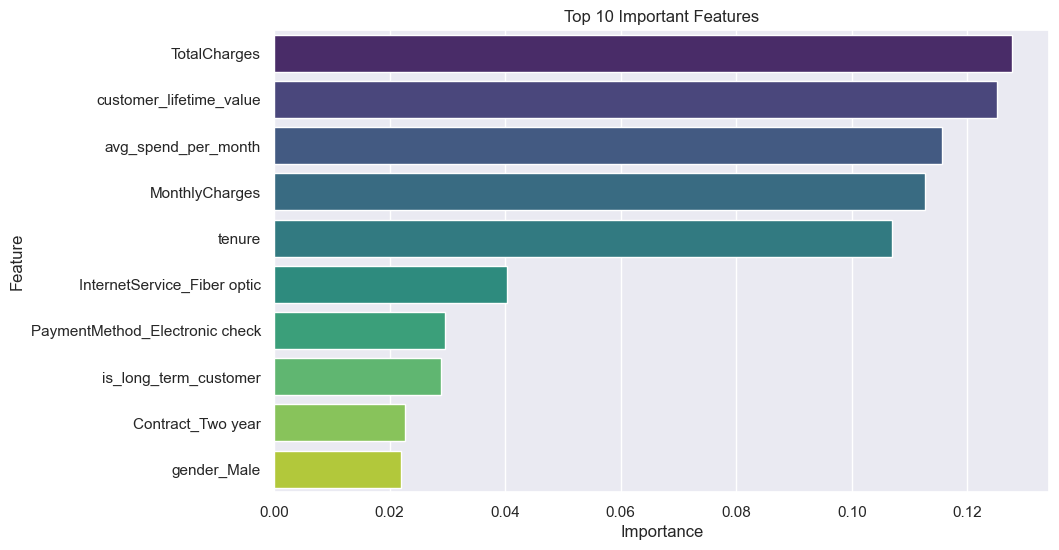

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="viridis"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

### Top Churn Correlations

In [24]:
print(
    df.select_dtypes(
        include=np.number
    )
    .corr()["churn"]
    .sort_values(
        ascending=False
    )
)

churn                      1.000000
churn_probability          0.894132
MonthlyCharges             0.193356
SeniorCitizen              0.150889
avg_spend_per_month        0.014873
customer_lifetime_value   -0.198514
TotalCharges              -0.199037
is_long_term_customer     -0.311496
tenure                    -0.352229
Name: churn, dtype: float64


### High-Risk Customers

In [30]:
high_risk = df[
    df["risk_category"]
    == "High Risk"
]

print(high_risk.head())

high_risk.to_csv(
    "High_Risk_Customers.csv",
    index=False
)

    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
2   3668-QPYBK    Male              0      No         No       2          Yes   
4   9237-HQITU  Female              0      No         No       2          Yes   
5   9305-CDSKC  Female              0      No         No       8          Yes   
13  0280-XJGEX    Male              0      No         No      49          Yes   
20  8779-QRDMV    Male              1      No         No       1           No   

       MultipleLines InternetService OnlineSecurity  ... MonthlyCharges  \
2                 No             DSL            Yes  ...          53.85   
4                 No     Fiber optic             No  ...          70.70   
5                Yes     Fiber optic             No  ...          99.65   
13               Yes     Fiber optic             No  ...         103.70   
20  No phone service             DSL             No  ...          39.65   

   TotalCharges Churn churn avg_spend_per_month customer_lifet